In [1]:
!pip install opencv-python numpy matplotlib

/bin/bash: pip: command not found


🚀 Nike Logo Detector started

🔍 Searching for logo...
✅ Logo found! (Match: 0.593)


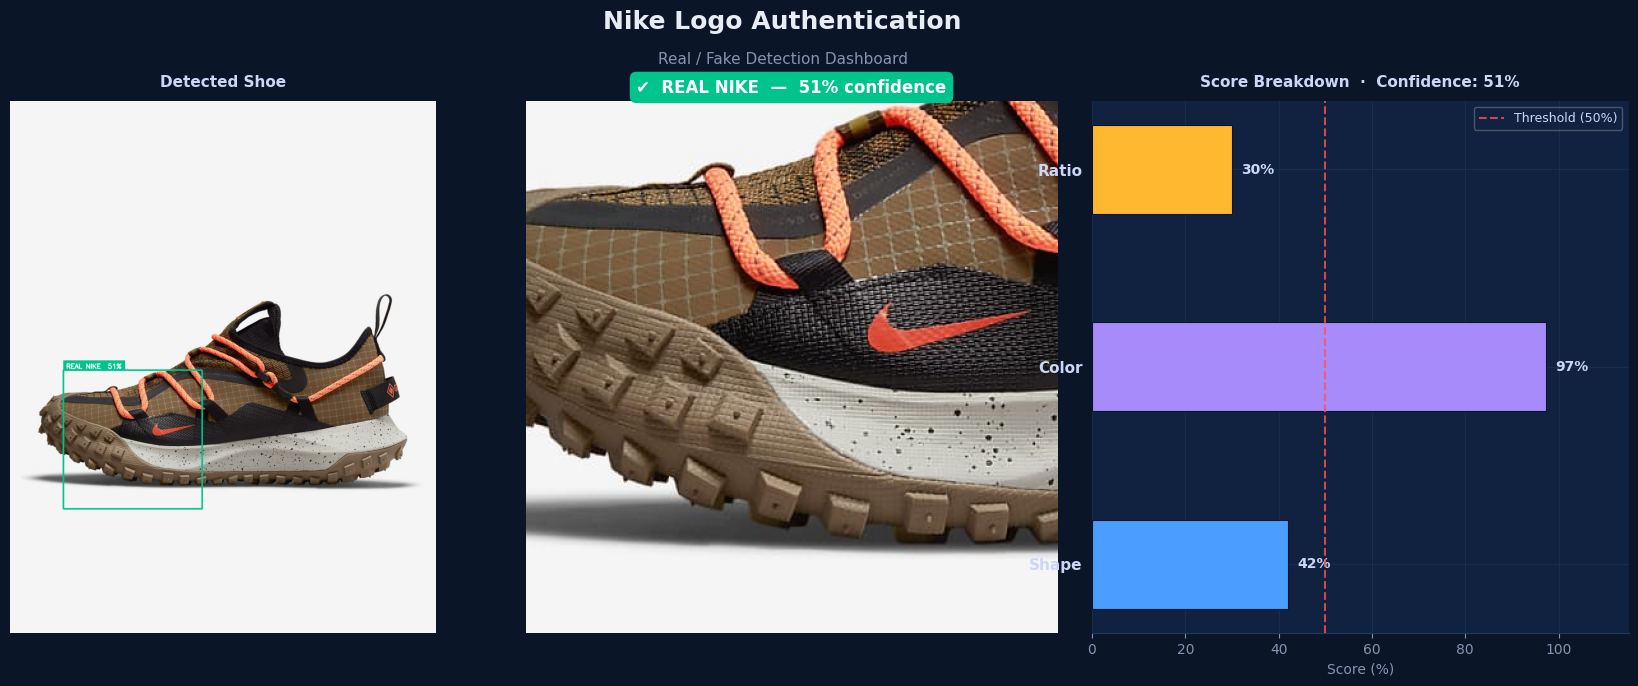


─────────────────────────────────────────────────────────────────
  RESULT      : ✔ REAL NIKE
  CONFIDENCE  : 51%
  Shape: 42.0%  |  Color: 97.2%  |  Ratio: 30.0%
─────────────────────────────────────────────────────────────────


─────────────────────────────────────────────────────────────────
  ACCURACY EVALUATION  —  3 images
─────────────────────────────────────────────────────────────────
🔍 Searching for logo...
✅ Logo found! (Match: 0.593)
  ✔  acg-mountain-fly-low-gore-tex-se-mens-shoes-Xc5LHq.png Actual: REAL  Predicted: REAL  Conf: 51%
🔍 Searching for logo...
✅ Logo found! (Match: 0.568)
  ✘  acg-lowcate-mens-shoes-7Px0Lq.png      Actual: FAKE  Predicted: REAL  Conf: 61%
🔍 Searching for logo...
✅ Logo found! (Match: 0.563)
  ✔  air-force-1-impact-next-nature-big-kids-shoes-617Rzw.png Actual: REAL  Predicted: REAL  Conf: 68%

─────────────────────────────────────────────────────────────────
  OVERALL ACCURACY : 66.7%   (2/3 correct)
───────────────────────────────────────────

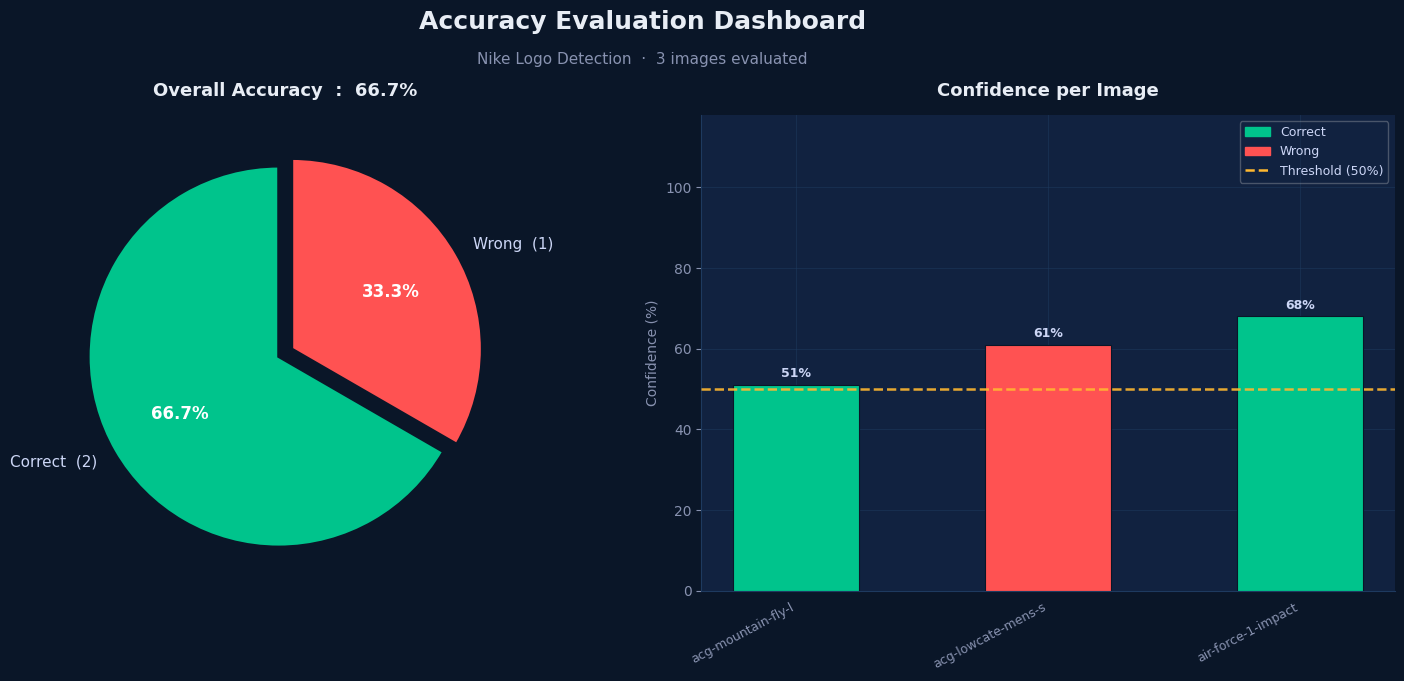

66.66666666666666

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import os

# ====================== SETTINGS ======================
TEMPLATE_PATH = "template2/nike.png"
MIN_MATCH = 0.36
REAL_THRESHOLD = 0.50
PADDING = 5
# ======================================================

# ====================== DASHBOARD THEME ======================
THEME = {
    "bg":         "#0A1628",   # Dark Blue background
    "card":       "#112240",   # Panel cards
    "primary":    "#E8EDF5",   # Titles
    "accent":     "#4A9EFF",   # Accent blue
    "success":    "#00C48C",   # Green
    "danger":     "#FF5252",   # Red
    "warning":    "#FFB830",   # Orange
    "text":       "#CCD6F6",   # Main text
    "subtext":    "#8892B0",   # Secondary text
    "border":     "#1E3A5F",   # Borders
    "bar_shape":  "#4A9EFF",
    "bar_color":  "#A78BFA",
    "bar_ratio":  "#FFB830",
}

def set_dashboard_style():
    plt.rcParams.update({
        "font.family":       "DejaVu Sans",
        "axes.facecolor":    THEME["card"],
        "figure.facecolor":  THEME["bg"],
        "axes.edgecolor":    THEME["border"],
        "axes.labelcolor":   THEME["text"],
        "xtick.color":       THEME["subtext"],
        "ytick.color":       THEME["subtext"],
        "text.color":        THEME["text"],
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "axes.grid":         True,
        "grid.color":        THEME["border"],
        "grid.linewidth":    0.8,
        "grid.alpha":        0.5,
    })
# =============================================================


def check_logo(logo_crop):
    if logo_crop is None or logo_crop.size == 0:
        return False, 0, {}

    gray    = cv2.cvtColor(logo_crop, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    edges   = cv2.Canny(thresh, 30, 150)

    moments = cv2.moments(edges)
    hu      = cv2.HuMoments(moments).flatten()
    hu_log  = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    ref     = np.array([0.19, 0.023, 0.001, 0.0008, 0.0, 0.0003, 0.0])
    ref_log = -np.sign(ref) * np.log10(np.abs(ref) + 1e-10)
    shape_score = float(np.clip(1.0 / (1.0 + np.mean(np.abs(hu_log[:7] - ref_log[:7])) * 0.22), 0, 1))

    total_px    = gray.shape[0] * gray.shape[1]
    color_score = float(np.clip((np.sum(gray < 70) + np.sum(gray > 180)) / total_px / 0.60, 0, 1))

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    ratio_score = 0.30
    if contours:
        _, _, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        ratio = w / h if h > 0 else 0
        if 1.3 <= ratio <= 6.5:
            ratio_score = float(np.clip(1.0 - abs(ratio - 3.0) / 4.5, 0, 1))

    total  = shape_score * 0.60 + color_score * 0.20 + ratio_score * 0.20
    scores = {"Shape": shape_score, "Color": color_score, "Ratio": ratio_score}
    return total >= REAL_THRESHOLD, round(total * 100), scores


def find_logo_in_image(image_path):
    shoe_img = cv2.imread(image_path)
    if shoe_img is None:
        print("❌ Image could not be opened!")
        return None, None
    if not os.path.exists(TEMPLATE_PATH):
        print("❌ template2/nike.png not found!")
        return None, shoe_img

    template = cv2.imread(TEMPLATE_PATH, cv2.IMREAD_GRAYSCALE)
    gray     = cv2.cvtColor(shoe_img, cv2.COLOR_BGR2GRAY)
    gray     = cv2.GaussianBlur(gray, (3, 3), 0)

    best_val = -1
    best_x = best_y = best_w = best_h = 0
    print("🔍 Searching for logo...")

    for scale in np.linspace(0.3, 2.4, 45):
        tw = int(template.shape[1] * scale)
        th = int(template.shape[0] * scale)
        if tw < 30 or th < 30 or tw > gray.shape[1] or th > gray.shape[0]:
            continue
        resized  = cv2.resize(template, (tw, th), interpolation=cv2.INTER_AREA)
        result   = cv2.matchTemplate(gray, resized, cv2.TM_CCOEFF_NORMED)
        _, max_val, _, max_loc = cv2.minMaxLoc(result)
        if max_val > best_val:
            best_val = max_val
            best_x, best_y = max_loc
            best_w, best_h = tw, th

    if best_val > MIN_MATCH:
        pad = PADDING
        x = max(0, best_x - pad)
        y = max(0, best_y - pad)
        w = min(shoe_img.shape[1] - x, best_w + pad * 2)
        h = min(shoe_img.shape[0] - y, best_h + pad * 2)
        print(f"✅ Logo found! (Match: {best_val:.3f})")
        return (x, y, w, h), shoe_img
    else:
        print(f"⚠️ Logo not found (best match: {best_val:.3f})")
        return None, shoe_img


def detect_logo(image_path):
    set_dashboard_style()
    location, shoe_img = find_logo_in_image(image_path)

    if location is None:
        fig, ax = plt.subplots(figsize=(10, 7), facecolor=THEME["bg"])
        ax.imshow(cv2.cvtColor(shoe_img, cv2.COLOR_BGR2RGB))
        ax.set_title("Nike logo not found", color=THEME["danger"], fontsize=14, fontweight="bold")
        ax.axis("off")
        plt.tight_layout()
        plt.show()
        return

    x, y, w, h = location
    logo_crop   = shoe_img[y:y+h, x:x+w]
    is_real, confidence, scores = check_logo(logo_crop)

    result_img  = cv2.cvtColor(shoe_img.copy(), cv2.COLOR_BGR2RGB)
    box_color   = (0, 196, 140)  if is_real else (255, 82, 82)
    label       = "REAL NIKE"    if is_real else "FAKE"

    cv2.rectangle(result_img, (x, y), (x+w, y+h), box_color, 3)
    badge_text = f"{label}  {confidence}%"
    (tw, th), _ = cv2.getTextSize(badge_text, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
    cv2.rectangle(result_img, (x, y - th - 14), (x + tw + 16, y), box_color, -1)
    cv2.putText(result_img, badge_text, (x + 8, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

    fig = plt.figure(figsize=(18, 7), facecolor=THEME["bg"])

    fig.text(0.5, 0.97, "Nike Logo Authentication",
             ha="center", va="top", fontsize=18, fontweight="bold",
             color=THEME["primary"])
    fig.text(0.5, 0.91, "Real / Fake Detection Dashboard",
             ha="center", va="top", fontsize=11, color=THEME["subtext"])

    gs = gridspec.GridSpec(1, 3, figure=fig,
                           left=0.04, right=0.97,
                           top=0.84, bottom=0.08,
                           wspace=0.06)

    # Panel 1: Full shoe
    ax0 = fig.add_subplot(gs[0])
    ax0.set_facecolor(THEME["card"])
    ax0.imshow(result_img)
    ax0.set_title("Detected Shoe", fontsize=11, fontweight="bold",
                  color=THEME["text"], pad=10)
    ax0.axis("off")

    # Panel 2: Logo crop
    ax1 = fig.add_subplot(gs[1])
    ax1.set_facecolor(THEME["card"])
    ax1.imshow(cv2.cvtColor(logo_crop, cv2.COLOR_BGR2RGB))
    ax1.axis("off")
    verdict_bg = THEME["success"] if is_real else THEME["danger"]
    icon       = "✔" if is_real else "✘"
    ax1.set_title(f"{icon}  {label}  —  {confidence}% confidence",
                  fontsize=12, fontweight="bold", color="white",
                  bbox=dict(boxstyle="round,pad=0.4",
                            facecolor=verdict_bg, edgecolor="none"))

    # Panel 3: Score bars
    ax2 = fig.add_subplot(gs[2])
    ax2.set_facecolor(THEME["card"])

    names  = ["Shape", "Color", "Ratio"]
    values = [scores[k] * 100 for k in names]
    colors = [THEME["bar_shape"], THEME["bar_color"], THEME["bar_ratio"]]
    y_pos  = np.arange(len(names))

    bars = ax2.barh(y_pos, values, color=colors,
                    height=0.45, zorder=3,
                    edgecolor=THEME["bg"], linewidth=0.8)

    ax2.axvline(REAL_THRESHOLD * 100, color=THEME["danger"],
                linestyle="--", linewidth=1.5, alpha=0.8, zorder=4,
                label=f"Threshold ({int(REAL_THRESHOLD*100)}%)")

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(names, fontsize=11, fontweight="bold", color=THEME["text"])
    ax2.set_xlim(0, 115)
    ax2.set_xlabel("Score (%)", fontsize=10, color=THEME["subtext"])
    ax2.set_title(f"Score Breakdown  ·  Confidence: {confidence}%",
                  fontsize=11, fontweight="bold", color=THEME["text"], pad=10)
    ax2.legend(fontsize=9, framealpha=0.3,
               facecolor=THEME["card"], labelcolor=THEME["text"])
    ax2.spines["left"].set_visible(False)
    ax2.tick_params(left=False)

    for bar, val in zip(bars, values):
        ax2.text(val + 2, bar.get_y() + bar.get_height() / 2,
                 f"{val:.0f}%", va="center", fontsize=10,
                 fontweight="bold", color=THEME["text"])

    plt.show()

    print(f"\n{'─'*65}")
    print(f"  RESULT      : {'✔ REAL NIKE' if is_real else '✘ FAKE'}")
    print(f"  CONFIDENCE  : {confidence}%")
    print(f"  Shape: {scores['Shape']*100:.1f}%  |  Color: {scores['Color']*100:.1f}%  |  Ratio: {scores['Ratio']*100:.1f}%")
    print(f"{'─'*65}\n")


# ====================== ACCURACY FUNCTION ======================
def evaluate_accuracy(test_folder, true_labels_dict):
    set_dashboard_style()

    correct = 0
    total   = len(true_labels_dict)
    results = []

    print(f"\n{'─'*65}")
    print(f"  ACCURACY EVALUATION  —  {total} images")
    print(f"{'─'*65}")

    for filename, true_label in true_labels_dict.items():
        img_path = os.path.join(test_folder, filename)
        if not os.path.exists(img_path):
            print(f"  ⚠  {filename} not found, skipped.")
            total -= 1
            continue

        location, shoe_img = find_logo_in_image(img_path)
        if location is None:
            predicted  = False
            confidence = 0
        else:
            x2, y2, w2, h2 = location
            logo_crop       = shoe_img[y2:y2+h2, x2:x2+w2]
            predicted, confidence, _ = check_logo(logo_crop)

        is_correct = (predicted == true_label)
        if is_correct:
            correct += 1

        p_label = "REAL" if predicted  else "FAKE"
        t_label = "REAL" if true_label else "FAKE"
        mark    = "✔"    if is_correct else "✘"
        results.append((filename, t_label, p_label, confidence, is_correct))
        print(f"  {mark}  {filename:<38} Actual: {t_label:<4}  Predicted: {p_label:<4}  Conf: {confidence}%")

    accuracy = (correct / total * 100) if total > 0 else 0
    wrong    = total - correct

    print(f"\n{'─'*65}")
    print(f"  OVERALL ACCURACY : {accuracy:.1f}%   ({correct}/{total} correct)")
    print(f"{'─'*65}\n")

    fig = plt.figure(figsize=(16, 7), facecolor=THEME["bg"])
    fig.text(0.5, 0.97, "Accuracy Evaluation Dashboard",
             ha="center", va="top", fontsize=18,
             fontweight="bold", color=THEME["primary"])
    fig.text(0.5, 0.91, f"Nike Logo Detection  ·  {total} images evaluated",
             ha="center", va="top", fontsize=11, color=THEME["subtext"])

    gs = gridspec.GridSpec(1, 2, figure=fig,
                           left=0.06, right=0.97,
                           top=0.82, bottom=0.14,
                           wspace=0.10)

    # Pie chart
    ax0 = fig.add_subplot(gs[0])
    ax0.set_facecolor(THEME["card"])
    wedges, texts, autotexts = ax0.pie(
        [correct, wrong],
        labels=[f"Correct  ({correct})", f"Wrong  ({wrong})"],
        colors=[THEME["success"], THEME["danger"]],
        explode=(0.04, 0.04),
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 11, "color": THEME["text"]},
        wedgeprops={"linewidth": 2, "edgecolor": THEME["bg"]}
    )
    for at in autotexts:
        at.set_fontsize(12)
        at.set_fontweight("bold")
        at.set_color("white")
    ax0.set_title(f"Overall Accuracy  :  {accuracy:.1f}%",
                  fontsize=13, fontweight="bold",
                  color=THEME["primary"], pad=14)

    # Bar chart
    ax1 = fig.add_subplot(gs[1])
    ax1.set_facecolor(THEME["card"])

    short_names = [r[0][:18] for r in results]
    confs       = [r[3]      for r in results]
    bar_colors  = [THEME["success"] if r[4] else THEME["danger"] for r in results]
    x_pos       = np.arange(len(results))

    bars = ax1.bar(x_pos, confs, color=bar_colors,
                   width=0.5, zorder=3,
                   edgecolor=THEME["bg"], linewidth=0.8)

    ax1.axhline(REAL_THRESHOLD * 100, color=THEME["warning"],
                linestyle="--", linewidth=1.8, alpha=0.9, zorder=4)

    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(short_names, rotation=28,
                        ha="right", fontsize=9, color=THEME["subtext"])
    ax1.set_ylim(0, 118)
    ax1.set_ylabel("Confidence (%)", fontsize=10, color=THEME["subtext"])
    ax1.set_title("Confidence per Image",
                  fontsize=13, fontweight="bold",
                  color=THEME["primary"], pad=14)

    correct_patch = mpatches.Patch(color=THEME["success"], label="Correct")
    wrong_patch   = mpatches.Patch(color=THEME["danger"],  label="Wrong")
    threshold_line = plt.Line2D([0], [0], color=THEME["warning"],
                                linestyle="--", linewidth=1.8,
                                label=f"Threshold ({int(REAL_THRESHOLD*100)}%)")
    ax1.legend(handles=[correct_patch, wrong_patch, threshold_line],
               fontsize=9, framealpha=0.3,
               facecolor=THEME["card"], labelcolor=THEME["text"])

    ax1.spines["left"].set_linewidth(0.8)
    ax1.tick_params(bottom=False)

    for bar, val in zip(bars, confs):
        ax1.text(bar.get_x() + bar.get_width() / 2, val + 2,
                 f"{val}%", ha="center", fontsize=9,
                 fontweight="bold", color=THEME["text"])

    plt.show()
    return accuracy
# ===============================================================


# ====================== USAGE ======================
# --- 1. Single image ---
image_path = "/Users/macstore.uz/Desktop/new project/Testing_Image2/acg-mountain-fly-low-gore-tex-se-mens-shoes-Xc5LHq.png"
print("🚀 Nike Logo Detector started\n")
detect_logo(image_path)

# --- 2. Accuracy ---
true_labels = {
    "acg-mountain-fly-low-gore-tex-se-mens-shoes-Xc5LHq.png": True,
    "acg-lowcate-mens-shoes-7Px0Lq.png": False,
    "air-force-1-impact-next-nature-big-kids-shoes-617Rzw.png": True,
}
evaluate_accuracy("Testing_Image2", true_labels)